# Evaluate NASA HDF5 and NetCDF files for cloud-optimized-ness

This report includes only files which inclue a data format attribute value of "NetCDF" or "HDF". There are other formats which include HDF or NetCDF:

* netCDF4-zipped3
* netCDF-3 - HDF-EOS22
* netCDF-4 - ASCII4
* netCDF-4 - netCDF-3
* HDF4 - netCDF-4

But they are very small in number (25) compared with the total of NetCDF and HDF tagged collections (1530 and 958, respectively)

In [1]:
import boto3
import earthaccess
import json
import os
import pandas as pd
from pathlib import Path
import re
import requests
import subprocess

# List all cloud-hosted NetCDF and HDF5 collections in Earthdata Cloud

In [2]:
%%time
# URL to which the POST request is sent
search_url = 'https://cmr.earthdata.nasa.gov/search/collections.json'
max_page_size = 2000 # the limit
collections = []
page_num = 1
while True:
    # taken from search.eartndata.nasa.gov
    form_data = f"cloud_hosted=true&has_granules_or_cwic=true&include_granule_counts=true&include_has_granules=true&page_num={page_num}&page_size={max_page_size}&granule_data_format_h[]=HDF&granule_data_format_h[]=NetCDF&sort_key[]=has_granules_or_cwic&sort_key[]=-usage_score"
    
    # Headers specifying the content type (important if the server expects form data)
    headers = {
        'Content-Type': 'application/x-www-form-urlencoded'
    }
    
    # Sending the POST request
    response = requests.post(search_url, data=form_data, headers=headers)
    
    # Print the status code and response text
    print("Status Code:", response.status_code)
    collection_response_json = json.loads(response.text)
    collections_list = collection_response_json['feed']['entry']
    num_collections = len(collections_list)
    print(f"Adding {num_collections} collections")
    collections.extend(collections_list)
    if num_collections < max_page_size:
        break
    else:
        page_num += 1

Status Code: 200
Adding 2000 collections
Status Code: 200
Adding 497 collections
CPU times: user 133 ms, sys: 68.4 ms, total: 202 ms
Wall time: 14 s


In [3]:
print(len(collections))

2497


# Start a dask cluster so we can parallelize inspecting these files

In [28]:
from dask_gateway import GatewayCluster, Gateway
import dask.bag as db

gateway = Gateway()
clusters = gateway.list_clusters()

# connect to an existing cluster - this is useful when the kernel shutdown in the middle of an interactive session
if clusters:
    cluster = gateway.connect(clusters[0].name)
else:
    options = gateway.cluster_options()
    # Set environment variables
    options.environment = {
        "EARTHDATA_USERNAME": os.environ['EARTHDATA_USERNAME'],
        "EARTHDATA_PASSWORD": os.environ['EARTHDATA_PASSWORD']
    }
    cluster = gateway.new_cluster(cluster_options=options)

cluster.scale(16)
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: /services/dask-gateway/clusters/prod.f884ae528b5e4f909160d7062dae2a43/status,


In [25]:
#cluster.close()

# Define a function to download the files and run h5stat

In [45]:
def process_file(collection: dict):
    s3 = boto3.resource('s3')
    dataset_dict = {}
    earthaccess.login(strategy="environment")
    short_name, version, data_center = collection['short_name'], collection['version_id'], collection['data_center']
    if data_center == 'NSIDC_CPRD':
        data_center = 'NSIDC'
    if data_center == 'LPCLOUD':
        data_center = 'LPDAAC'
    if data_center == 'POCLOUD':
        data_center = 'PODAAC'
    if data_center == 'OB_CLOUD':
        data_center = 'OBDAAC'
    if data_center == 'ORNL_CLOUD':
        data_center = 'ORNLDAAC'
    if data_center == 'GHRC_DAAC':
        data_center = 'GHRCDAAC'

    try: 
        daac_credentials = earthaccess.get_s3_credentials(daac=data_center)
    
        # get 1 result
        results = earthaccess.search_data(
            short_name=short_name,
            cloud_hosted=True,
            version=version,
            count=1
        )
        data_link = results[0].data_links(access="direct")[0]
    
        source_session = boto3.Session(
            aws_access_key_id=daac_credentials['accessKeyId'],
            aws_secret_access_key=daac_credentials['secretAccessKey'],
            aws_session_token=daac_credentials['sessionToken']
        )
        source_s3 = source_session.client('s3')
        
        # Define the source bucket and key
        source_bucket_name = data_link.split('/')[2]
        source_key = data_link.split(source_bucket_name + '/')[1]
    
        filename = source_key.split('/')[-1]


        # Step 2: Download file, run h5stat and return results
        if os.path.exists(filename):
            print(f"The {filename} already been downloaded.")
        else:
            source_s3.download_file(source_bucket_name, source_key, filename)
        dataset_dict[filename] = {
            'collection': short_name,
            'version': version,
            'direct_link': data_link,
            'filename': filename,
            # note: just added this, not present in current version of output
            'data_center': data_center
        }    
        # Function to parse the h5stat output
        def parse_h5stat_output(output):
            # Regular expressions to find file space management strategy and page size
            fsm_strategy_pattern = r"File space management strategy:\s+(\w+)"
            page_size_pattern = r"File space page size:\s+(\d+)"
        
            # Search for file space management strategy
            fsm_strategy_match = re.search(fsm_strategy_pattern, output)
            fsm_strategy = fsm_strategy_match.group(1) if fsm_strategy_match else "Not found"
        
            # Search for file space page size
            page_size_match = re.search(page_size_pattern, output)
            page_size = page_size_match.group(1) if page_size_match else "Not found"
        
            return fsm_strategy, page_size

        try:
            result = subprocess.run(['h5stat', filename], capture_output=True, text=True, check=True)
            output = result.stdout
        except subprocess.CalledProcessError as e:
            # print(f"Failed to run h5stat: {e}, perhaps this file is not hdf5?")
            output = ""
        
        fsm_strategy, page_size = parse_h5stat_output(output)
        dataset_dict[filename]['fsm_strategy'] = fsm_strategy
        dataset_dict[filename]['page_size'] = page_size
        os.remove(filename)
        return dataset_dict
    except Exception as e:
        return f"Caught exception {e} while trying to process file from collection {short_name}, version {version}"
    

# Run the function on Dask

In [46]:
%%time
bag = db.from_sequence(collections, partition_size=1)
result = db.map(process_file, bag)
all_files = result.compute()

/srv/conda/envs/notebook/lib/python3.11/site-packages/distributed/client.py:3157: UserWarning: Sending large graph of size 11.60 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


CPU times: user 5.96 s, sys: 401 ms, total: 6.36 s
Wall time: 23min 54s


And write the output.

In [47]:
import json
with open('hdf_cmr_query_results.json', 'w+') as f:
    f.write(json.dumps(all_files))

# Plot paged aggregation and page size

In [65]:
import pandas as pd
data_json = json.loads(open('hdf_cmr_query_results.json', 'r').read())
# remove some which had errors
filtered_list = [list(item.values())[0] for item in data_json if isinstance(item, dict)]
df = pd.DataFrame(data=filtered_list)

In [71]:
df.head()

,collection,version,direct_link,filename,fsm_strategy,page_size
0,ATL03,006,s3://nsidc-cumulus-prod-protected/ATLAS/ATL03/...,ATL03_20181014000347_02350101_006_02.h5,H5F_FSPACE_STRATEGY_FSM_AGGR,4096
1,ATL08,006,s3://nsidc-cumulus-prod-protected/ATLAS/ATL08/...,ATL08_20181014001049_02350102_006_02.h5,H5F_FSPACE_STRATEGY_FSM_AGGR,4096
2,AIRIBRAD,005,s3://gesdisc-cumulus-prod-protected/Aqua_AIRS_...,AIRS.2002.08.30.225.L1B.AIRS_Rad.v5.0.0.0.G071...,Not found,Not found
3,OMVFPITMET,003,s3://gesdisc-cumulus-prod-protected/Aura_OMI_L...,OMI-Aura_ANC-OMVFPITMET_2004m1001t000305-o0113...,H5F_FSPACE_STRATEGY_FSM_AGGR,4096
4,OMUFPITMET,003,s3://gesdisc-cumulus-prod-protected/Aura_OMI_L...,OMI-Aura_ANC-OMUFPITMET_2004m1001t000305-o0113...,H5F_FSPACE_STRATEGY_FSM_AGGR,4096


In [78]:
print(f"There are {len(df)} collections which were successfully downloaded.")

There are 2382 reported.


In [87]:
print(f"`h5stat` failed on {len(df[df['page_size'] == 'Not found'])} collections. These may not be hdf5.")

`h5stat` failed on 472 collections.


# Plot results 

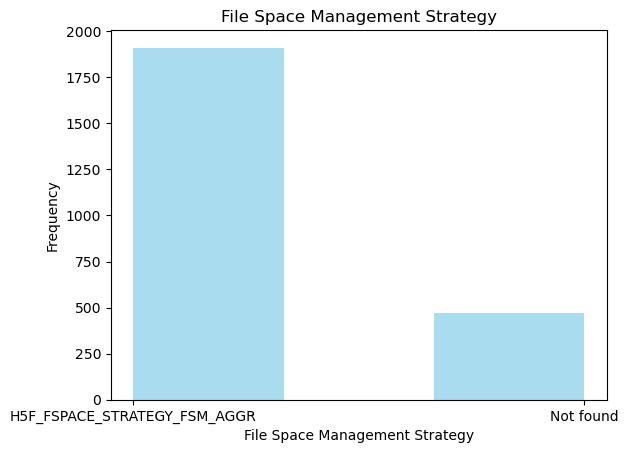

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
column_data = df['fsm_strategy']
plt.hist(column_data, bins=3, color='skyblue', alpha=0.7)
plt.title('File Space Management Strategy')
plt.xlabel('File Space Management Strategy')
plt.ylabel('Frequency')
plt.show()

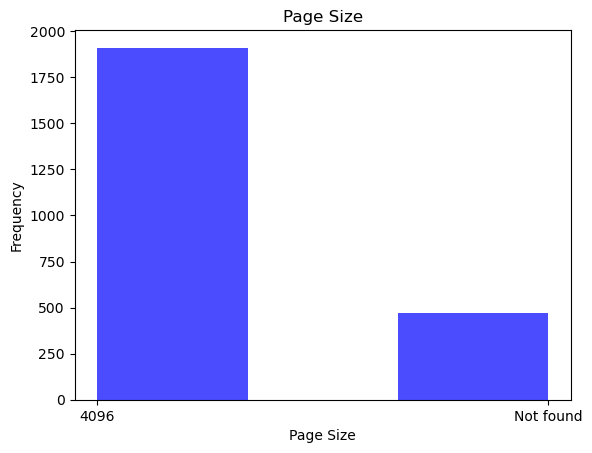

In [75]:
column_data = df['page_size']
plt.hist(column_data, bins=3, color='blue', alpha=0.7)
plt.title('Page Size')
plt.xlabel('Page Size')
plt.ylabel('Frequency')
plt.show()